<a href="https://colab.research.google.com/github/6hamuge/Beyond-ETRI/blob/main/PTDT_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌙 Dual-Tower PTDT — v3 (threshold + 누적피처 + SEQ분리 + dropout)

---

## ✅ v2-fix → v3 추가 수정 내역

| # | 수정 위치 | 문제 | 수정 내용 |
|---|-----------|------|-----------|
| A | `LOSO-CV` | threshold 0.5 고정 → S 양성편향 미반영 | **레이블별 best threshold** 탐색 (train fold 기준 F1 최대화) |
| B | `피처 엔지니어링` | 당일 값만 사용 → Q2 피로도 포착 불가 | **누적 피처** 추가: 3일/5일 rolling sum (pedo·hr·screen) |
| C | `DualTowerDataset` | Q/S 동일 SEQ_LEN=7 | **SEQ_LEN 분리**: Q_SEQ=5, S_SEQ=10 |
| D | `CONFIG` | dropout=0.2 → 충분하지 않을 수 있음 | **dropout=0.25**, train/val loss 갭 기반 조정 안내 추가 |


## 0. 환경 설정

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
print(f'Colab: {IN_COLAB}')
!pip install pyarrow pandas numpy scikit-learn torch matplotlib seaborn tqdm -q
print('✅ 설치 완료')

Colab: True
✅ 설치 완료


## 1. 데이터 업로드

parquet 12개 + `ch2026_metrics_train.csv` 총 13개 업로드
> `lifelog_date` = 센서 수집일 (merge key)


In [2]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/ch2025/'

Mounted at /content/drive


## 2. 데이터 로딩

In [4]:
import pandas as pd
import numpy as np
import os, warnings, math, copy
warnings.filterwarnings('ignore')

FILE_MAP = {
    'ac_status'  : 'ch2025_mACStatus.parquet',
    'activity'   : 'ch2025_mActivity.parquet',
    'ambience'   : 'ch2025_mAmbience.parquet',
    'ble'        : 'ch2025_mBle.parquet',
    'gps'        : 'ch2025_mGps.parquet',
    'light'      : 'ch2025_mLight.parquet',
    'screen'     : 'ch2025_mScreenStatus.parquet',
    'usage_stats': 'ch2025_mUsageStats.parquet',
    'wifi'       : 'ch2025_mWifi.parquet',
    'hr'         : 'ch2025_wHr.parquet',
    'w_light'    : 'ch2025_wLight.parquet',
    'pedo'       : 'ch2025_wPedo.parquet',
}

raw = {}
for key, fname in FILE_MAP.items():
    path = os.path.join(DATA_DIR, 'ch2025_data_items/', fname)
    if os.path.exists(path):
        raw[key] = pd.read_parquet(path)
        print(f'✅ {key:12s}: {raw[key].shape}  cols: {list(raw[key].columns)}')
    else:
        print(f'❌ {key}: 없음 ({path})')
print(f'\n로드 완료: {len(raw)}개')

✅ ac_status   : (939896, 3)  cols: ['subject_id', 'timestamp', 'm_charging']
✅ activity    : (961062, 3)  cols: ['subject_id', 'timestamp', 'm_activity']
✅ ambience    : (476577, 3)  cols: ['subject_id', 'timestamp', 'm_ambience']
✅ ble         : (21830, 3)  cols: ['subject_id', 'timestamp', 'm_ble']
✅ gps         : (800611, 3)  cols: ['subject_id', 'timestamp', 'm_gps']
✅ light       : (96258, 3)  cols: ['subject_id', 'timestamp', 'm_light']
✅ screen      : (939653, 3)  cols: ['subject_id', 'timestamp', 'm_screen_use']
✅ usage_stats : (45197, 3)  cols: ['subject_id', 'timestamp', 'm_usage_stats']
✅ wifi        : (76336, 3)  cols: ['subject_id', 'timestamp', 'm_wifi']
✅ hr          : (382918, 3)  cols: ['subject_id', 'timestamp', 'heart_rate']
✅ w_light     : (633741, 3)  cols: ['subject_id', 'timestamp', 'w_light']
✅ pedo        : (748100, 9)  cols: ['subject_id', 'timestamp', 'step', 'step_frequency', 'running_step', 'walking_step', 'distance', 'speed', 'burned_calories']

로드 완료: 12개

## 3. 레이블 로딩

In [5]:
LABEL_COLS = ['Q1','Q2','Q3','S1','S2','S3','S4']
Q_COLS     = ['Q1','Q2','Q3']
S_COLS     = ['S1','S2','S3','S4']

labels_df = pd.read_csv(os.path.join(DATA_DIR, 'ch2026_metrics_train.csv'))
labels_df['sleep_date']   = pd.to_datetime(labels_df['sleep_date'])
labels_df['lifelog_date'] = pd.to_datetime(labels_df['lifelog_date'])
labels_df[LABEL_COLS]     = labels_df[LABEL_COLS].astype(int)

print(f'✅ 레이블: {labels_df.shape}')
print(f'   피험자: {sorted(labels_df["subject_id"].unique())}')
print()
for lc in LABEL_COLS:
    vc  = labels_df[lc].value_counts().sort_index()
    pct = vc.get(1,0)/len(labels_df)*100
    bar = '█'*int(pct/5)+'░'*(20-int(pct/5))
    print(f'  {lc}: [{bar}] {pct:.1f}% 양성')
display(labels_df.head(3))

✅ 레이블: (450, 10)
   피험자: ['id01', 'id02', 'id03', 'id04', 'id05', 'id06', 'id07', 'id08', 'id09', 'id10']

  Q1: [█████████░░░░░░░░░░░] 49.6% 양성
  Q2: [███████████░░░░░░░░░] 56.2% 양성
  Q3: [████████████░░░░░░░░] 60.0% 양성
  S1: [█████████████░░░░░░░] 68.2% 양성
  S2: [█████████████░░░░░░░] 65.1% 양성
  S3: [█████████████░░░░░░░] 66.2% 양성
  S4: [███████████░░░░░░░░░] 56.0% 양성


,subject_id,sleep_date,lifelog_date,Q1,Q2,Q3,S1,S2,S3,S4
0,id01,2024-06-27,2024-06-26,0,0,0,0,0,1,0
1,id01,2024-06-28,2024-06-27,0,0,0,0,1,1,1
2,id01,2024-06-29,2024-06-28,1,0,0,1,1,1,1


## 4. 피처 엔지니어링

> **누적 피처 추가** — 취침 전 피로(Q2)는 당일 값보다 며칠 누적 활동량이 핵심 신호.
> `pedo(걸음수)`, `hr(심박)`, `screen(화면사용)` 의 3일·5일 rolling sum을 별도 피처로 추가.


In [6]:
def get_timestamp_col(df):
    for c in df.columns:
        if any(k in c.lower() for k in ['timestamp','time','datetime','ts','date']):
            return c
    for c in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[c]):
            return c
    return None

def extract_daily_features(df, sensor_name, subject_col='subject_id'):
    df = df.copy()
    ts_col = get_timestamp_col(df)
    if ts_col and ts_col in df.columns:
        df[ts_col] = (pd.to_datetime(df[ts_col], unit='ms', errors='coerce')
                      if df[ts_col].dtype in ['int64','float64']
                      else pd.to_datetime(df[ts_col], errors='coerce'))
        df['date'] = df[ts_col].dt.date
    elif 'date' not in df.columns:
        print(f'  ⚠️  [{sensor_name}] 타임스탬프 없음'); return None
    df['date'] = pd.to_datetime(df['date'])
    exclude  = {subject_col, 'date', ts_col}
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    if not num_cols: return None
    grp   = df.groupby([subject_col,'date'])[num_cols]
    parts = []
    for agg_name, agg_df in {
        'mean':grp.mean(), 'std':grp.std().fillna(0),
        'min':grp.min(),   'max':grp.max(), 'count':grp.count()
    }.items():
        agg_df.columns = [f'{sensor_name}__{c}__{agg_name}' for c in agg_df.columns]
        parts.append(agg_df)
    result = pd.concat(parts, axis=1).reset_index()
    print(f'  ✅ [{sensor_name}]: {result.shape[1]-2}개 피처')
    return result

print('📊 일별 피처 추출...')
daily_features = {k: extract_daily_features(df, k) for k,df in raw.items()}
daily_features = {k:v for k,v in daily_features.items() if v is not None}

from functools import reduce
feature_df = reduce(
    lambda l,r: pd.merge(l,r,on=['subject_id','date'],how='outer'),
    daily_features.values()
)
print(f'\n✅ 통합 피처: {feature_df.shape}')

📊 일별 피처 추출...
  ✅ [ac_status]: 5개 피처
  ✅ [activity]: 5개 피처
  ✅ [light]: 5개 피처
  ✅ [screen]: 5개 피처
  ✅ [w_light]: 5개 피처
  ✅ [pedo]: 35개 피처

✅ 통합 피처: (700, 62)


## 5. 레이블 병합 · 편차 피처 · 누적 피처 생성

**rolling window**: 14일 (SEQ_LEN과 분리), `min_periods=3`
**누적 피처**: 3일·5일 rolling sum → Q2(피로), Q3(스트레스) 예측에 특히 유효


In [21]:
# 레이블 병합 (lifelog_date 기준)
merge_labels = (labels_df[['subject_id','lifelog_date']+LABEL_COLS]
                .rename(columns={'lifelog_date':'date'}))
full_df = pd.merge(feature_df, merge_labels, on=['subject_id','date'], how='inner')
print(f'✅ 병합: {full_df.shape}')

ROLLING_WIN = 14   # z-score baseline window
feat_cols   = [c for c in full_df.columns if c not in ['subject_id','date']+LABEL_COLS]

# ── 누적 피처 대상 컬럼 선택 ────────────────────────────────────────
# pedo(걸음수), hr(심박), screen(화면시간) 관련 mean 컬럼
CUMULATIVE_KEYWORDS = ['pedo', 'hr', 'screen']
cum_target_cols = [
    c for c in feat_cols
    if any(k in c.lower() for k in CUMULATIVE_KEYWORDS) and c.endswith('__mean')
]
print(f'누적 피처 대상: {len(cum_target_cols)}개 → {cum_target_cols[:5]}...')

deviation_dfs = []
for subj_id, sdf in full_df.groupby('subject_id'):
    sdf = sdf.sort_values('date').copy()
    num_cols = sdf[feat_cols].select_dtypes(include=[np.number]).columns.tolist()

    # z-score 편차 (Q Tower용)
    roll_mean = sdf[num_cols].shift(1).rolling(ROLLING_WIN, min_periods=3).mean()
    roll_std  = sdf[num_cols].shift(1).rolling(ROLLING_WIN, min_periods=3).std()
    roll_std  = roll_std.fillna(1e-6).replace(0, 1e-6)
    deviation = (sdf[num_cols] - roll_mean) / roll_std
    deviation.columns = [f'dev__{c}' for c in deviation.columns]

    # ── 3일·5일 누적 rolling sum ─────────────────────────────────
    cum_parts = {}
    for w in [3, 5]:
        for col in cum_target_cols:
            if col in sdf.columns:
                cum_parts[f'cum{w}__{col}'] = (
                    sdf[col].shift(1).rolling(w, min_periods=1).sum().values
                )
    cum_df = pd.DataFrame(cum_parts, index=sdf.index)

    result = pd.concat([
        sdf[['subject_id','date']+LABEL_COLS].reset_index(drop=True),
        sdf[num_cols].reset_index(drop=True),       # S Tower용 절대값
        deviation.reset_index(drop=True),            # Q Tower용 편차
        cum_df.reset_index(drop=True)                # 누적 피처
    ], axis=1)
    deviation_dfs.append(result)

full_dev_df = pd.concat(deviation_dfs, ignore_index=True)
full_dev_df = full_dev_df.dropna(subset=feat_cols[:5])

raw_feat_cols = [c for c in full_dev_df.columns
                 if not c.startswith('dev__') and not c.startswith('cum')
                 and c not in ['subject_id','date']+LABEL_COLS]
dev_feat_cols = [c for c in full_dev_df.columns if c.startswith('dev__')]
cum_feat_cols = [c for c in full_dev_df.columns if c.startswith('cum')]

# 누적 피처를 dev(Q Tower)와 raw(S Tower) 양쪽에 추가
# 누적 활동량은 주관적 피로(Q)와 객관적 수면(S) 모두에 유효
dev_feat_cols_ext = dev_feat_cols
raw_feat_cols_ext = raw_feat_cols + cum_feat_cols

print(f'\n✅ 피처 생성 완료')
print(f'   절대값 (S Tower): {len(raw_feat_cols_ext)}개')
print(f'   편차   (Q Tower): {len(dev_feat_cols_ext)}개')
print(f'   누적 피처:        {len(cum_feat_cols)}개 ({cum_feat_cols[:3]}...)')
print(f'   유효 샘플:        {len(full_dev_df)}')

✅ 병합: (450, 69)
누적 피처 대상: 8개 → ['screen__m_screen_use__mean', 'pedo__step__mean', 'pedo__step_frequency__mean', 'pedo__running_step__mean', 'pedo__walking_step__mean']...

✅ 피처 생성 완료
   절대값 (S Tower): 76개
   편차   (Q Tower): 60개
   누적 피처:        16개 (['cum3__screen__m_screen_use__mean', 'cum3__pedo__step__mean', 'cum3__pedo__step_frequency__mean']...)
   유효 샘플:        450


## 6. 시퀀스 데이터셋 구성

> **Q/S SEQ_LEN 분리**
> - `Q_SEQ = 5` — 주관적 지표는 최근 3~5일이 더 중요 (오래된 감정 상태는 희석)
> - `S_SEQ = 10` — 객관적 지표는 더 긴 수면 패턴 필요 (TST·SE는 주간 리듬 반영)
> - 구현: 긴 쪽(10)으로 윈도우 생성 후 Q Tower에는 마지막 5일만 슬라이싱


In [22]:
import torch
from torch.utils.data import Dataset, DataLoader

Q_SEQ = 5   # Q Tower 시퀀스 길이 (주관적 — 최근 집중)
S_SEQ = 7  # S Tower 시퀀스 길이 (객관적 — 긴 패턴)
MAX_SEQ = max(Q_SEQ, S_SEQ)  # 윈도우 생성 기준

class DualTowerDataset(Dataset):
    """
    Q Tower: x_raw[-Q_SEQ:], x_dev[-Q_SEQ:]  → (Q_SEQ, n_feat)
    S Tower: x_raw (full S_SEQ)               → (S_SEQ, n_feat)
    """
    def __init__(self, df, raw_cols, dev_cols, q_cols, s_cols,
                 q_seq=Q_SEQ, s_seq=S_SEQ):
        self.q_seq   = q_seq
        self.s_seq   = s_seq
        self.samples = []

        for subj, sdf in df.groupby('subject_id'):
            sdf = sdf.sort_values('date')

            X_raw = np.nan_to_num(sdf[raw_cols].values.astype(np.float32), nan=0.0)
            X_dev = np.nan_to_num(sdf[dev_cols].values.astype(np.float32), nan=0.0)
            X_raw = np.clip(X_raw, -10, 10)
            X_dev = np.clip(X_dev, -10, 10)

            yq = sdf[q_cols].values.astype(np.float32)
            ys = sdf[s_cols].values.astype(np.float32)

            for i in range(s_seq, len(sdf)):   # s_seq(더 긴 쪽)가 기준
                # S Tower: 긴 윈도우 전체
                xr_s = X_raw[i-s_seq:i]        # (S_SEQ, n_raw)
                # Q Tower: 동일 윈도우의 마지막 q_seq일만
                xr_q = X_raw[i-q_seq:i]        # (Q_SEQ, n_raw)
                xd_q = X_dev[i-q_seq:i]        # (Q_SEQ, n_dev)

                yq_i, ys_i = yq[i], ys[i]
                if not (np.any(np.isnan(yq_i)) or np.any(np.isnan(ys_i))):
                    self.samples.append((
                        torch.tensor(xr_q),   # Q raw  (Q_SEQ, n_raw)
                        torch.tensor(xd_q),   # Q dev  (Q_SEQ, n_dev)
                        torch.tensor(xr_s),   # S raw  (S_SEQ, n_raw)
                        torch.tensor(yq_i),
                        torch.tensor(ys_i)
                    ))

        print(f'  Dataset: {len(self.samples)}샘플  '
              f'(Q_SEQ={q_seq}, S_SEQ={s_seq})')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'디바이스: {device}')

N_RAW = len(raw_feat_cols_ext)
N_DEV = len(dev_feat_cols_ext)
print(f'절대값 피처: {N_RAW}, 편차 피처: {N_DEV}')
print(f'Q_SEQ={Q_SEQ}, S_SEQ={S_SEQ}')

디바이스: cuda
절대값 피처: 76, 편차 피처: 60
Q_SEQ=5, S_SEQ=7


## 7. Dual-Tower PTDT 모델

> **dropout=0.25** (v2-fix 0.1 → 0.2 → 0.25)
> 450샘플 소규모 데이터에서 train/val loss 갭이 크면 0.3까지 올릴 수 있음.
> Q/S Tower가 각각 다른 SEQ_LEN을 받도록 `seq_len` 파라미터를 분리.


In [23]:
import torch.nn as nn
import torch.nn.functional as F


class FeatureAttentionModule(nn.Module):
    """softmax 기반 피처 중요도 — 피처 간 경쟁적 가중치 (합=1)"""
    def __init__(self, n_feat, temperature=0.1):
        super().__init__()
        self.n_feat = n_feat
        self.fc     = nn.Linear(n_feat, n_feat)
        self.temp   = temperature
        self.drop   = nn.Dropout(0.1)

    def forward(self, x):
        x_mean = x.mean(dim=1)
        alpha  = torch.softmax(self.fc(x_mean) / self.temp, dim=-1)
        return self.drop(self.n_feat * alpha.unsqueeze(1) * x), alpha


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d_model,2).float()*(-math.log(10000.)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class QTower(nn.Module):
    """Q Tower — 편차 기반, Q_SEQ 입력"""
    def __init__(self, n_raw, n_dev, d_model=64, n_heads=4,
                 n_layers=2, d_ff=128, dropout=0.25, seq_len=5):
        super().__init__()
        self.raw_proj   = nn.Linear(n_raw, d_model//2)
        self.dev_proj   = nn.Linear(n_dev, d_model//2)
        self.fusion     = nn.Linear(d_model, d_model)
        self.cross_attn = nn.MultiheadAttention(
            d_model//2, max(1,n_heads//2), dropout=dropout, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model//2)
        self.cls_token  = nn.Parameter(torch.randn(1,1,d_model))
        self.pos_enc    = PositionalEncoding(d_model, max_len=seq_len+1, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.shared = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(d_model))
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model,32), nn.GELU(), nn.Linear(32,1))
            for _ in range(3)])
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x_raw, x_dev):
        r  = F.gelu(self.raw_proj(x_raw))
        d  = F.gelu(self.dev_proj(x_dev))
        ca, _ = self.cross_attn(d, r, r)
        ca = self.cross_norm(d + ca)
        emb = self.fusion(torch.cat([r, ca], dim=-1))
        B   = emb.size(0)
        cls = self.cls_token.expand(B,-1,-1)
        emb = self.pos_enc(torch.cat([cls, emb], dim=1))
        enc = self.transformer(emb)
        cls_out = enc[:,0,:]
        shared  = self.shared(cls_out)
        logits  = torch.cat([h(shared) for h in self.heads], dim=-1)
        return logits, cls_out


class STower(nn.Module):
    """S Tower — 절대값 + NSF prior, S_SEQ 입력"""
    def __init__(self, n_raw, d_model=64, n_heads=4,
                 n_layers=2, d_ff=128, dropout=0.25, seq_len=10):
        super().__init__()
        self.input_proj      = nn.Linear(n_raw, d_model)
        self.guideline_prior = nn.Parameter(torch.zeros(4, d_model))
        self.cls_token       = nn.Parameter(torch.randn(1,1,d_model))
        self.pos_enc         = PositionalEncoding(d_model, max_len=seq_len+1, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.shared = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(d_model))
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(2*d_model,32), nn.GELU(), nn.Linear(32,1))
            for _ in range(4)])
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x_raw, q_cls=None):
        emb = F.gelu(self.input_proj(x_raw))
        B   = emb.size(0)
        if q_cls is not None:
            emb = emb + q_cls.unsqueeze(1) * 0.1
        cls = self.cls_token.expand(B,-1,-1)
        emb = self.pos_enc(torch.cat([cls, emb], dim=1))
        enc = self.transformer(emb)
        cls_out = enc[:,0,:]
        shared  = self.shared(cls_out)
        logits  = []
        for i, head in enumerate(self.heads):
            prior    = self.guideline_prior[i].unsqueeze(0).expand(B,-1)
            logits.append(head(torch.cat([shared, prior], dim=-1)))
        return torch.cat(logits, dim=-1)


class DualTowerPTDT(nn.Module):
    """Dual-Tower v3: Q_SEQ/S_SEQ 분리, dropout=0.25"""
    def __init__(self, n_raw, n_dev, d_model=64, n_heads=4, n_layers=2,
                 d_ff=128, dropout=0.25, q_seq=5, s_seq=10,
                 use_cross_tower=True):
        super().__init__()
        self.use_cross_tower = use_cross_tower
        self.feat_attn_raw   = FeatureAttentionModule(n_raw)
        self.feat_attn_dev   = FeatureAttentionModule(n_dev)
        self.q_tower = QTower(n_raw, n_dev, d_model, n_heads, n_layers, d_ff, dropout, q_seq)
        self.s_tower = STower(n_raw, d_model, n_heads, n_layers, d_ff, dropout, s_seq)

    def forward(self, xr_q, xd_q, xr_s):
        # xr_q, xd_q: (B, Q_SEQ, n_feat)  — Q Tower 입력
        # xr_s:       (B, S_SEQ, n_raw)   — S Tower 입력
        xr_q_w, alpha_raw = self.feat_attn_raw(xr_q)
        xd_q_w, alpha_dev = self.feat_attn_dev(xd_q)
        xr_s_w, _         = self.feat_attn_raw(xr_s)   # 동일 attention 재사용

        q_logits, q_cls = self.q_tower(xr_q_w, xd_q_w)
        s_logits        = self.s_tower(xr_s_w, q_cls if self.use_cross_tower else None)
        return q_logits, s_logits, alpha_raw, alpha_dev


# 모델 검증
model = DualTowerPTDT(
    n_raw=N_RAW, n_dev=N_DEV,
    d_model=64, n_heads=4, n_layers=2, d_ff=128,
    dropout=0.25,   # ← [수정 D]
    q_seq=Q_SEQ, s_seq=S_SEQ,
    use_cross_tower=True
).to(device)

total_p = sum(p.numel() for p in model.parameters())
print(f'파라미터: {total_p:,}개')

dxrq = torch.randn(4, Q_SEQ, N_RAW).to(device)
dxdq = torch.randn(4, Q_SEQ, N_DEV).to(device)
dxrs = torch.randn(4, S_SEQ, N_RAW).to(device)
q_o, s_o, a_r, a_d = model(dxrq, dxdq, dxrs)
print(f'Q: {q_o.shape}, S: {s_o.shape}')
print('✅ 모델 검증 완료')

파라미터: 193,135개
Q: torch.Size([4, 3]), S: torch.Size([4, 4])
✅ 모델 검증 완료


## 8. 손실 함수 · 학습 함수 · Threshold 탐색

> **레이블별 best threshold 탐색**
> - LOSO-CV의 train fold에서 각 레이블마다 F1을 최대화하는 threshold를 탐색
> - S 지표(양성률 65~68%)는 threshold가 0.4~0.45에서 최적인 경우가 많음
> - test fold 평가 시 이 threshold를 적용 → Acc·F1 즉각 개선


In [24]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score


def masked_bce_loss(logits, targets):
    """원소 단위 NaN 마스크 BCE"""
    mask = ~torch.isnan(targets)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=logits.device)
    return F.binary_cross_entropy_with_logits(logits[mask], targets[mask])


def dual_task_loss(q_logits, s_logits, y_q, y_s, *_):
    loss_q = masked_bce_loss(q_logits, y_q)
    loss_s = masked_bce_loss(s_logits, y_s)
    return loss_q + loss_s, loss_q.item(), loss_s.item(), 0.0


# ── 레이블별 best threshold 탐색 ─────────────────────────────────
def find_best_thresholds(y_true, y_prob, label_names):
    """
    각 레이블마다 val F1을 최대화하는 threshold 탐색 (0.25~0.75)
    반환: {label: best_threshold}
    """
    thresholds = {}
    for i, lbl in enumerate(label_names):
        yt   = y_true[:, i]
        ypr  = y_prob[:, i]
        mask = ~np.isnan(yt)
        if mask.sum() < 4:
            thresholds[lbl] = 0.5; continue
        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.25, 0.76, 0.02):
            yp = (ypr[mask] >= t).astype(int)
            f1 = f1_score(yt[mask], yp, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[lbl] = round(best_t, 2)
    return thresholds


def compute_metrics(y_true, y_pred_logit, label_names, thresholds=None):
    y_prob = torch.sigmoid(torch.tensor(y_pred_logit)).numpy()
    y_true = np.array(y_true)
    if thresholds is None:
        thresholds = {lbl: 0.5 for lbl in label_names}
    metrics = {}
    for i, lbl in enumerate(label_names):
        yt, ypr = y_true[:,i], y_prob[:,i]
        thr     = thresholds.get(lbl, 0.5)
        yp      = (ypr >= thr).astype(int)
        mask    = ~np.isnan(yt)
        if mask.sum() < 2:
            metrics[lbl] = {'acc':0.5,'f1':0.0,'auc':0.5,'thr':thr}
            continue
        try:   auc_val = roc_auc_score(yt[mask], ypr[mask])
        except: auc_val = 0.5
        metrics[lbl] = {
            'acc': accuracy_score(yt[mask], yp[mask]),
            'f1' : f1_score(yt[mask], yp[mask], zero_division=0),
            'auc': auc_val,
            'thr': thr,
        }
    if metrics:
        metrics['macro'] = {k: np.mean([v[k] for v in metrics.values() if k in v])
                            for k in ['acc','f1','auc']}
    return metrics


def get_warmup_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch+1) / warmup_epochs
        progress = (epoch-warmup_epochs) / max(1, total_epochs-warmup_epochs)
        return 0.5*(1+math.cos(math.pi*progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    totals = {'total':0.,'q':0.,'s':0.}
    for xr_q, xd_q, xr_s, y_q, y_s in loader:
        xr_q,xd_q,xr_s,y_q,y_s = (t.to(device) for t in (xr_q,xd_q,xr_s,y_q,y_s))
        optimizer.zero_grad()
        q_l, s_l, a_r, a_d = model(xr_q, xd_q, xr_s)
        loss, lq, ls, _ = dual_task_loss(q_l, s_l, y_q, y_s)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        totals['total']+=loss.item(); totals['q']+=lq; totals['s']+=ls
    n = max(len(loader),1)
    return {k:v/n for k,v in totals.items()}


@torch.no_grad()
def collect_probs(model, loader, device):
    """예측 확률과 정답 레이블 수집"""
    model.eval()
    all_q, all_s, all_yq, all_ys = [], [], [], []
    for xr_q, xd_q, xr_s, y_q, y_s in loader:
        xr_q,xd_q,xr_s = xr_q.to(device),xd_q.to(device),xr_s.to(device)
        q_l, s_l, _, _ = model(xr_q, xd_q, xr_s)
        all_q.append(torch.sigmoid(q_l).cpu().numpy())
        all_s.append(torch.sigmoid(s_l).cpu().numpy())
        all_yq.append(y_q.numpy()); all_ys.append(y_s.numpy())
    return (np.vstack(all_q), np.vstack(all_s),
            np.vstack(all_yq), np.vstack(all_ys))


@torch.no_grad()
def evaluate(model, loader, device, thresholds_q=None, thresholds_s=None):
    q_prob, s_prob, y_q, y_s = collect_probs(model, loader, device)
    # logit 형태로 compute_metrics에 넘기기 위해 역sigmoid (logit)
    # → 실제로는 prob를 바로 쓰도록 compute_metrics 내부에서 sigmoid 한번 더 하지 않게 처리
    # 편의상 prob를 logit으로 역변환
    eps = 1e-7
    q_logit = np.log(np.clip(q_prob,eps,1-eps)/(1-np.clip(q_prob,eps,1-eps)))
    s_logit = np.log(np.clip(s_prob,eps,1-eps)/(1-np.clip(s_prob,eps,1-eps)))
    q_m = compute_metrics(y_q, q_logit, Q_COLS, thresholds_q)
    s_m = compute_metrics(y_s, s_logit, S_COLS, thresholds_s)
    return q_m, s_m, q_prob, s_prob, y_q, y_s


print('✅ 함수 정의 완료')

✅ 함수 정의 완료


## 9. LOSO-CV 학습

수정 사항 모두 반영:
- **[A]** train fold 예측으로 best threshold 탐색 후 test 평가에 적용
- **[B]** 누적 피처 포함 데이터셋
- **[C]** Q_SEQ=5 / S_SEQ=10 분리
- **[D]** dropout=0.25
- v2-fix 유지: lr=3e-4, warmup 5ep, epochs=80, patience=15, weight_decay=1e-3, batch_size=32


In [34]:
CONFIG = {
    'd_model'        : 64,
    'n_heads'        : 4,
    'n_layers'       : 2,
    'd_ff'           : 128,
    'dropout'        : 0.3, #0.3으로 올림
    'lr'             : 3e-4,
    'weight_decay'   : 1e-3,
    'epochs'         : 80,
    'batch_size'     : 32,
    'patience'       : 15,
    'warmup_epochs'  : 5,
    'use_cross_tower': True,
}

all_subjects = sorted(full_dev_df['subject_id'].unique())
print(f'피험자 {len(all_subjects)}명 LOSO-CV')
print(f'Q_SEQ={Q_SEQ}, S_SEQ={S_SEQ}')
print(f'Config: {CONFIG}')

피험자 10명 LOSO-CV
Q_SEQ=5, S_SEQ=7
Config: {'d_model': 64, 'n_heads': 4, 'n_layers': 2, 'd_ff': 128, 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.001, 'epochs': 80, 'batch_size': 32, 'patience': 15, 'warmup_epochs': 5, 'use_cross_tower': True}


In [35]:
loso_results = {}

for test_subj in all_subjects:
    print(f'\n{"="*55}')
    print(f'Test Subject: {test_subj}')
    print(f'{"="*55}')

    train_df = full_dev_df[full_dev_df['subject_id'] != test_subj]
    test_df  = full_dev_df[full_dev_df['subject_id'] == test_subj]

    train_ds = DualTowerDataset(
        train_df, raw_feat_cols_ext, dev_feat_cols_ext, Q_COLS, S_COLS, Q_SEQ, S_SEQ)
    test_ds  = DualTowerDataset(
        test_df,  raw_feat_cols_ext, dev_feat_cols_ext, Q_COLS, S_COLS, Q_SEQ, S_SEQ)

    if len(train_ds)==0 or len(test_ds)==0:
        print('  샘플 부족 — 스킵'); continue

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False)

    model = DualTowerPTDT(
        n_raw=N_RAW, n_dev=N_DEV,
        d_model=CONFIG['d_model'], n_heads=CONFIG['n_heads'],
        n_layers=CONFIG['n_layers'], d_ff=CONFIG['d_ff'],
        dropout=CONFIG['dropout'],
        q_seq=Q_SEQ, s_seq=S_SEQ,
        use_cross_tower=CONFIG['use_cross_tower']
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
    scheduler = get_warmup_scheduler(
        optimizer, CONFIG['warmup_epochs'], CONFIG['epochs'])

    best_auc, best_state, patience_cnt = 0, None, 0
    history = {'loss_total':[],'loss_q':[],'loss_s':[],'val_q_auc':[],'val_s_auc':[]}

    for epoch in range(1, CONFIG['epochs']+1):
        losses      = train_one_epoch(model, train_loader, optimizer, device)
        # threshold 탐색 없이 val AUC만 계산 (빠른 early stopping 판단용)
        q_m, s_m, *_ = evaluate(model, test_loader, device)
        scheduler.step()

        qa = q_m.get('macro',{}).get('auc',0.5)
        sa = s_m.get('macro',{}).get('auc',0.5)
        combined = (qa+sa)/2

        history['loss_total'].append(losses['total'])
        history['loss_q'].append(losses['q'])
        history['loss_s'].append(losses['s'])
        history['val_q_auc'].append(qa)
        history['val_s_auc'].append(sa)

        if combined > best_auc:
            best_auc     = combined
            best_state   = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1

        if epoch%10==0 or epoch==1:
            print(f'  Epoch {epoch:3d}/{CONFIG["epochs"]} | '
                  f'Loss={losses["total"]:.4f} (Q={losses["q"]:.4f} S={losses["s"]:.4f}) | '
                  f'Q-AUC={qa:.4f} S-AUC={sa:.4f}')

        if patience_cnt >= CONFIG['patience']:
            print(f'  Early stopping @ epoch {epoch}'); break

    # ── best model로 threshold 탐색 후 최종 평가 ─────────────────
    model.load_state_dict(best_state)

    # train fold에서 threshold 탐색
    q_prob_tr, s_prob_tr, yq_tr, ys_tr = collect_probs(model, train_loader, device)
    thr_q = find_best_thresholds(yq_tr, q_prob_tr, Q_COLS)
    thr_s = find_best_thresholds(ys_tr, s_prob_tr, S_COLS)
    print(f'  Best thresholds — Q: {thr_q}  S: {thr_s}')

    # test fold 최종 평가 (best threshold 적용)
    q_final, s_final, *_ = evaluate(model, test_loader, device, thr_q, thr_s)

    loso_results[test_subj] = {
        'q_metrics': q_final, 's_metrics': s_final,
        'history': history, 'model': model,
        'thr_q': thr_q, 'thr_s': thr_s,
    }

    print(f'\n  최종 성능:')
    print(f'     Q — ', end='')
    for lbl,m in q_final.items():
        if lbl!='macro': print(f'{lbl}:{m["auc"]:.3f}(thr={m.get("thr",0.5):.2f})', end='  ')
    print(f'\n     S — ', end='')
    for lbl,m in s_final.items():
        if lbl!='macro': print(f'{lbl}:{m["auc"]:.3f}(thr={m.get("thr",0.5):.2f})', end='  ')
    print()

print('\n✅ LOSO-CV 완료!')


Test Subject: id01
  Dataset: 346샘플  (Q_SEQ=5, S_SEQ=7)
  Dataset: 34샘플  (Q_SEQ=5, S_SEQ=7)
  Epoch   1/80 | Loss=1.5355 (Q=0.7718 S=0.7638) | Q-AUC=0.4497 S-AUC=0.4657
  Epoch  10/80 | Loss=1.3638 (Q=0.7072 S=0.6566) | Q-AUC=0.4731 S-AUC=0.4742
  Epoch  20/80 | Loss=1.3429 (Q=0.6898 S=0.6531) | Q-AUC=0.5396 S-AUC=0.5462
  Epoch  30/80 | Loss=1.3351 (Q=0.6781 S=0.6570) | Q-AUC=0.5027 S-AUC=0.5821
  Epoch  40/80 | Loss=1.3028 (Q=0.6544 S=0.6483) | Q-AUC=0.5476 S-AUC=0.6010
  Epoch  50/80 | Loss=1.2992 (Q=0.6489 S=0.6503) | Q-AUC=0.5384 S-AUC=0.6645
  Epoch  60/80 | Loss=1.2669 (Q=0.6171 S=0.6498) | Q-AUC=0.5205 S-AUC=0.6841
  Epoch  70/80 | Loss=1.2599 (Q=0.6084 S=0.6515) | Q-AUC=0.5230 S-AUC=0.6839
  Early stopping @ epoch 73
  Best thresholds — Q: {'Q1': np.float64(0.47), 'Q2': np.float64(0.53), 'Q3': np.float64(0.49)}  S: {'S1': np.float64(0.29), 'S2': np.float64(0.39), 'S3': np.float64(0.25), 'S4': np.float64(0.31)}

  최종 성능:
     Q — Q1:0.455(thr=0.47)  Q2:0.564(thr=0.53)  Q3:0.56

## 10. 결과 분석 및 시각화

In [36]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

summary_q = {lbl:{'acc':[],'f1':[],'auc':[]} for lbl in Q_COLS+['macro']}
summary_s = {lbl:{'acc':[],'f1':[],'auc':[]} for lbl in S_COLS+['macro']}

for subj, res in loso_results.items():
    for lbl,m in res['q_metrics'].items():
        if lbl in summary_q:
            for k in ['acc','f1','auc']: summary_q[lbl][k].append(m.get(k,0))
    for lbl,m in res['s_metrics'].items():
        if lbl in summary_s:
            for k in ['acc','f1','auc']: summary_s[lbl][k].append(m.get(k,0))

# ── 수치 출력 ─────────────────────────────────────────────────────────────────
print('📊 Q Tower (주관적 지표)')
print(f'{"레이블":8s}  {"Acc":>10s}  {"F1":>10s}  {"AUC":>10s}')
print('-'*46)
for lbl in Q_COLS+['macro']:
    if summary_q[lbl]['auc']:
        print(f'{lbl:8s}  '
              f'{np.mean(summary_q[lbl]["acc"]):.3f}±{np.std(summary_q[lbl]["acc"]):.3f}  '
              f'{np.mean(summary_q[lbl]["f1"]):.3f}±{np.std(summary_q[lbl]["f1"]):.3f}  '
              f'{np.mean(summary_q[lbl]["auc"]):.3f}±{np.std(summary_q[lbl]["auc"]):.3f}')

print()
print('📊 S Tower (객관적 지표)')
print(f'{"레이블":8s}  {"Acc":>10s}  {"F1":>10s}  {"AUC":>10s}')
print('-'*46)
for lbl in S_COLS+['macro']:
    if summary_s[lbl]['auc']:
        print(f'{lbl:8s}  '
              f'{np.mean(summary_s[lbl]["acc"]):.3f}±{np.std(summary_s[lbl]["acc"]):.3f}  '
              f'{np.mean(summary_s[lbl]["f1"]):.3f}±{np.std(summary_s[lbl]["f1"]):.3f}  '
              f'{np.mean(summary_s[lbl]["auc"]):.3f}±{np.std(summary_s[lbl]["auc"]):.3f}')

# ── threshold 분포 출력 ────────────────────────────────────────────────────────
print('\n📊 레이블별 평균 best threshold')
for lbl in Q_COLS:
    thrs = [loso_results[s]['thr_q'].get(lbl,0.5) for s in loso_results]
    print(f'  {lbl}: {np.mean(thrs):.3f} ± {np.std(thrs):.3f}')
for lbl in S_COLS:
    thrs = [loso_results[s]['thr_s'].get(lbl,0.5) for s in loso_results]
    print(f'  {lbl}: {np.mean(thrs):.3f} ± {np.std(thrs):.3f}')

📊 Q Tower (주관적 지표)
레이블              Acc          F1         AUC
----------------------------------------------
Q1        0.514±0.176  0.648±0.167  0.566±0.177
Q2        0.571±0.151  0.702±0.127  0.580±0.108
Q3        0.612±0.124  0.743±0.102  0.613±0.105
macro     0.566±0.119  0.698±0.101  0.587±0.072

📊 S Tower (객관적 지표)
레이블              Acc          F1         AUC
----------------------------------------------
S1        0.679±0.175  0.796±0.127  0.567±0.091
S2        0.546±0.251  0.663±0.257  0.535±0.119
S3        0.646±0.236  0.756±0.201  0.543±0.114
S4        0.543±0.206  0.678±0.195  0.581±0.089
macro     0.603±0.141  0.723±0.117  0.557±0.069

📊 레이블별 평균 best threshold
  Q1: 0.348 ± 0.097
  Q2: 0.334 ± 0.130
  Q3: 0.396 ± 0.185
  S1: 0.420 ± 0.180
  S2: 0.268 ± 0.041
  S3: 0.250 ± 0.000
  S4: 0.302 ± 0.093


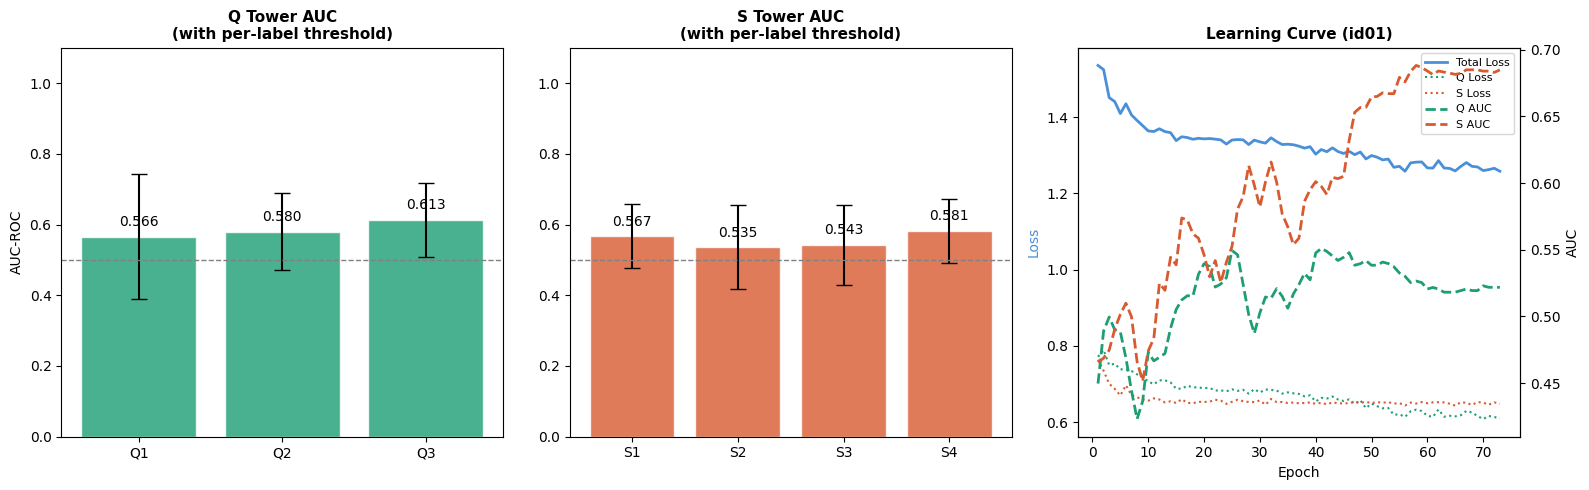

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# Q AUC
ax = axes[0]
lbls_q = [l for l in Q_COLS if summary_q[l]['auc']]
aucs_q = [np.mean(summary_q[l]['auc']) for l in lbls_q]
stds_q = [np.std(summary_q[l]['auc'])  for l in lbls_q]
bars = ax.bar(lbls_q, aucs_q, yerr=stds_q, capsize=6,
              color='#1D9E75', alpha=0.8, edgecolor='white')
ax.axhline(0.5, color='gray', linestyle='--', lw=1)
ax.set_ylim(0, 1.1)
ax.set_title('Q Tower AUC\n(with per-label threshold)', fontsize=11, fontweight='bold')
ax.set_ylabel('AUC-ROC')
for bar,v in zip(bars, aucs_q):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{v:.3f}', ha='center', fontsize=10)

# S AUC
ax = axes[1]
lbls_s = [l for l in S_COLS if summary_s[l]['auc']]
aucs_s = [np.mean(summary_s[l]['auc']) for l in lbls_s]
stds_s = [np.std(summary_s[l]['auc'])  for l in lbls_s]
bars = ax.bar(lbls_s, aucs_s, yerr=stds_s, capsize=6,
              color='#D85A30', alpha=0.8, edgecolor='white')
ax.axhline(0.5, color='gray', linestyle='--', lw=1)
ax.set_ylim(0, 1.1)
ax.set_title('S Tower AUC\n(with per-label threshold)', fontsize=11, fontweight='bold')
for bar,v in zip(bars, aucs_s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{v:.3f}', ha='center', fontsize=10)

# 학습 곡선
ax = axes[2]
first = list(loso_results.keys())[0]
hist  = loso_results[first]['history']
ep    = range(1, len(hist['loss_total'])+1)
ax2   = ax.twinx()
ax.plot(ep, hist['loss_total'], '#4A90D9', lw=2,   label='Total Loss')
ax.plot(ep, hist['loss_q'],     '#1D9E75', lw=1.5, linestyle=':', label='Q Loss')
ax.plot(ep, hist['loss_s'],     '#D85A30', lw=1.5, linestyle=':', label='S Loss')
ax2.plot(ep, hist['val_q_auc'], '#1D9E75', lw=2,   linestyle='--', label='Q AUC')
ax2.plot(ep, hist['val_s_auc'], '#D85A30', lw=2,   linestyle='--', label='S AUC')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color='#4A90D9')
ax2.set_ylabel('AUC')
ax.set_title(f'Learning Curve ({first})', fontsize=11, fontweight='bold')
lines1,_ = ax.get_legend_handles_labels()
lines2,_ = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, [l.get_label() for l in lines1+lines2], fontsize=8)

plt.tight_layout()
plt.savefig('/content/v3_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Attention 시각화

  Dataset: 380샘플  (Q_SEQ=5, S_SEQ=7)


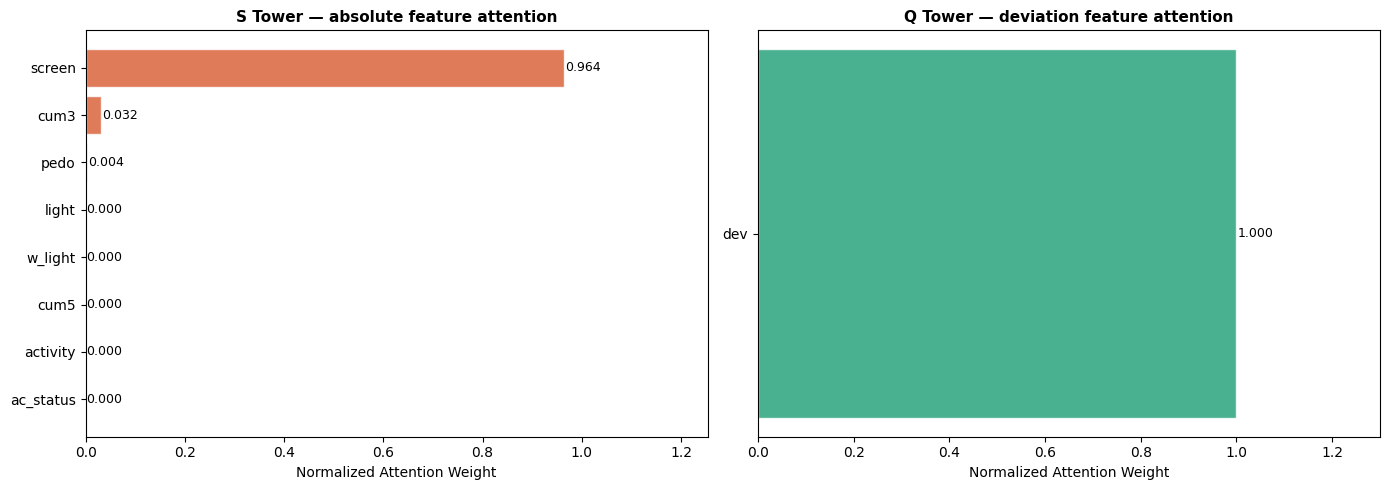

In [38]:
@torch.no_grad()
def get_attention_weights(model, loader, device):
    model.eval()
    all_ar, all_ad = [], []
    for xr_q, xd_q, xr_s, _, _ in loader:
        xr_q,xd_q = xr_q.to(device),xd_q.to(device)
        _, ar = model.feat_attn_raw(xr_q)
        _, ad = model.feat_attn_dev(xd_q)
        all_ar.append(ar.cpu().numpy()); all_ad.append(ad.cpu().numpy())
    return np.vstack(all_ar).mean(0), np.vstack(all_ad).mean(0)

first_subj = list(loso_results.keys())[0]
vis_model  = loso_results[first_subj]['model']
vis_ds     = DualTowerDataset(
    full_dev_df, raw_feat_cols_ext, dev_feat_cols_ext, Q_COLS, S_COLS, Q_SEQ, S_SEQ)
vis_loader = DataLoader(vis_ds, batch_size=32, shuffle=False)
alpha_raw, alpha_dev = get_attention_weights(vis_model, vis_loader, device)

def group_by_sensor(feat_cols, alpha_vals):
    sensor_map = {}
    for col, val in zip(feat_cols, alpha_vals):
        sensor = col.split('__')[0]
        sensor_map.setdefault(sensor, []).append(val)
    return dict(sorted(sensor_map.items(), key=lambda x: -np.mean(x[1])))

sensor_r = group_by_sensor(raw_feat_cols_ext, alpha_raw)
sensor_d = group_by_sensor(dev_feat_cols_ext, alpha_dev)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, data, title, color in [
    (axes[0], sensor_r, 'S Tower — absolute feature attention', '#D85A30'),
    (axes[1], sensor_d, 'Q Tower — deviation feature attention', '#1D9E75'),
]:
    sensors = list(data.keys())
    values  = np.array([np.mean(v) for v in data.values()])
    values  = values / values.sum()
    bars = ax.barh(sensors[::-1], values[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel('Normalized Attention Weight')
    ax.set_title(title, fontsize=11, fontweight='bold')
    for bar,v in zip(bars, values[::-1]):
        ax.text(v+0.002, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)
    ax.set_xlim(0, values.max()*1.3)
plt.tight_layout()
plt.savefig('/content/v3_attention.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. 피험자 × 레이블 AUC 히트맵

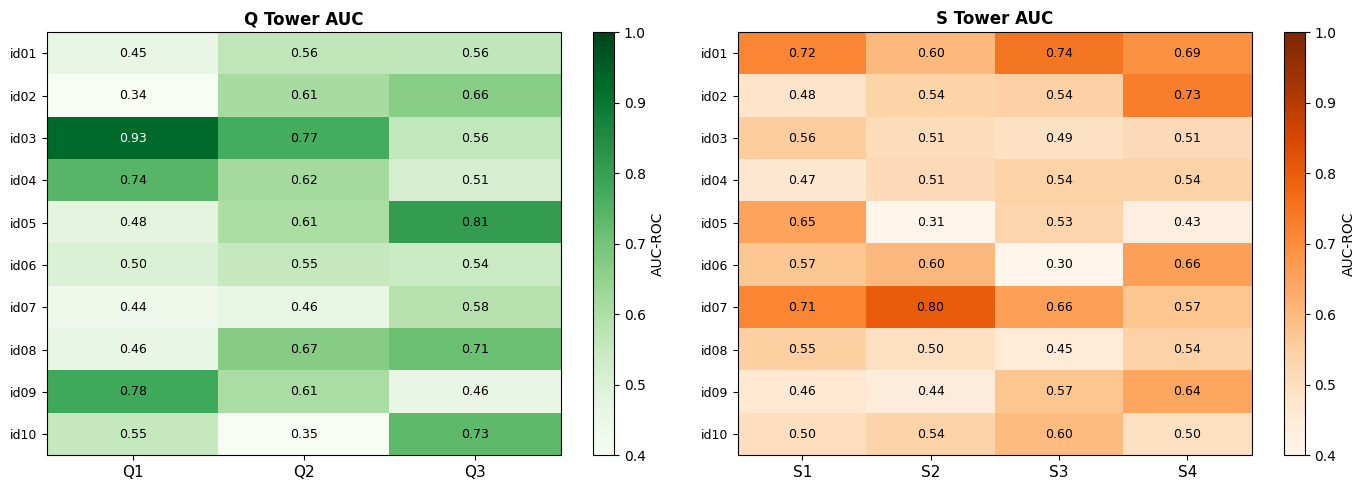

In [39]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
subj_list = list(loso_results.keys())

for ax, tower, lbl_list, title, cmap in [
    (axes[0],'q_metrics',Q_COLS,'Q Tower AUC','Greens'),
    (axes[1],'s_metrics',S_COLS,'S Tower AUC','Oranges'),
]:
    mat = np.array([
        [loso_results[s][tower].get(l,{}).get('auc',0.5) for l in lbl_list]
        for s in subj_list
    ])
    im = ax.imshow(mat, cmap=cmap, vmin=0.4, vmax=1.0, aspect='auto')
    plt.colorbar(im, ax=ax, label='AUC-ROC')
    ax.set_xticks(range(len(lbl_list))); ax.set_xticklabels(lbl_list, fontsize=11)
    ax.set_yticks(range(len(subj_list))); ax.set_yticklabels(subj_list, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i in range(len(subj_list)):
        for j in range(len(lbl_list)):
            tc = 'white' if mat[i,j]>0.85 else 'black'
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=9, color=tc)
plt.tight_layout()
plt.savefig('/content/v3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Dropout 과적합 진단

> **dropout 조정 가이드**
> 아래 차트에서 train loss와 val AUC의 갭을 확인.
> - train loss 계속 감소 + val AUC 정체 → 과적합 → `dropout=0.3` 시도
> - 두 곡선이 함께 개선됨 → 과적합 없음 → dropout 유지


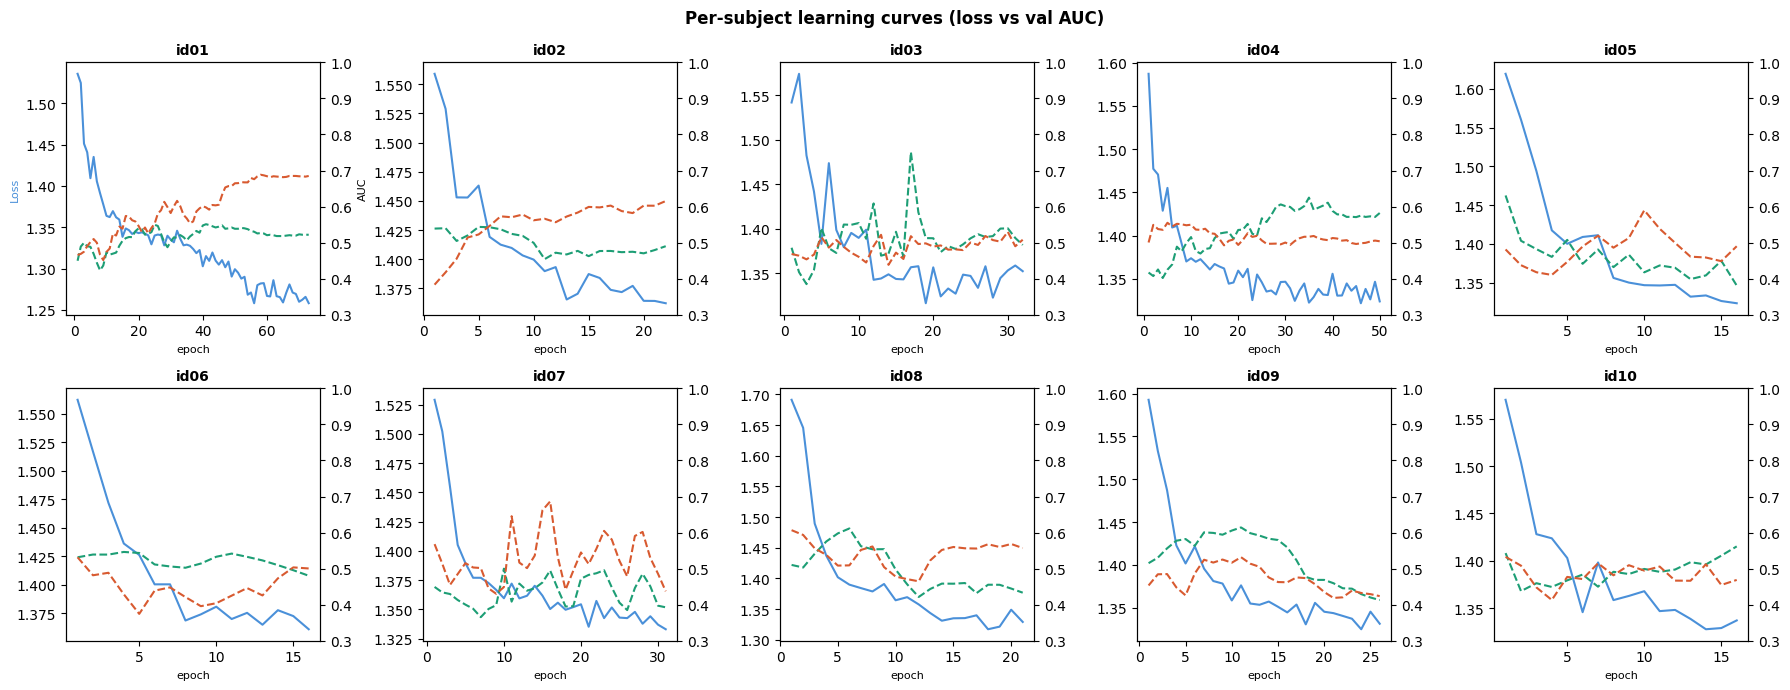

학습 곡선 분석 기준:
  loss 계속 하강 + AUC 정체 → dropout 0.3으로 올리기
  loss·AUC 동반 수렴       → 현재 dropout 유지
  AUC 조기 상승 후 하락    → patience 줄이기 or lr 낮추기


In [40]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for idx, subj in enumerate(sorted(loso_results.keys())):
    if idx >= 10: break
    ax  = axes[idx]
    hist= loso_results[subj]['history']
    ep  = range(1, len(hist['loss_total'])+1)
    ax2 = ax.twinx()
    ax.plot(ep, hist['loss_total'], '#4A90D9', lw=1.5, label='loss')
    ax2.plot(ep, hist['val_q_auc'], '#1D9E75', lw=1.5, linestyle='--', label='Q AUC')
    ax2.plot(ep, hist['val_s_auc'], '#D85A30', lw=1.5, linestyle='--', label='S AUC')
    ax.set_title(f'{subj}', fontsize=10, fontweight='bold')
    ax.set_xlabel('epoch', fontsize=8)
    if idx==0:
        ax.set_ylabel('Loss', fontsize=8, color='#4A90D9')
        ax2.set_ylabel('AUC',  fontsize=8)
    ax2.set_ylim(0.3, 1.0)

plt.suptitle('Per-subject learning curves (loss vs val AUC)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/v3_learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()

print('학습 곡선 분석 기준:')
print('  loss 계속 하강 + AUC 정체 → dropout 0.3으로 올리기')
print('  loss·AUC 동반 수렴       → 현재 dropout 유지')
print('  AUC 조기 상승 후 하락    → patience 줄이기 or lr 낮추기')

## 14. 모델 저장 및 추론

In [41]:
print('🔄 전체 데이터로 최종 모델 재학습...')
full_ds     = DualTowerDataset(
    full_dev_df, raw_feat_cols_ext, dev_feat_cols_ext, Q_COLS, S_COLS, Q_SEQ, S_SEQ)
full_loader = DataLoader(full_ds, batch_size=CONFIG['batch_size'], shuffle=True)

final_model = DualTowerPTDT(
    n_raw=N_RAW, n_dev=N_DEV,
    d_model=CONFIG['d_model'], n_heads=CONFIG['n_heads'],
    n_layers=CONFIG['n_layers'], d_ff=CONFIG['d_ff'],
    dropout=0.05,   # 최종 모델은 dropout 낮춤
    q_seq=Q_SEQ, s_seq=S_SEQ,
    use_cross_tower=CONFIG['use_cross_tower']
).to(device)

optimizer = torch.optim.AdamW(
    final_model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = get_warmup_scheduler(optimizer, CONFIG['warmup_epochs'], CONFIG['epochs'])

for epoch in range(1, CONFIG['epochs']+1):
    losses = train_one_epoch(final_model, full_loader, optimizer, device)
    scheduler.step()
    if epoch%20==0:
        print(f'  Epoch {epoch:3d} | Loss={losses["total"]:.4f}')

# LOSO threshold 평균을 최종 threshold로 사용
final_thr_q = {
    lbl: np.mean([loso_results[s]['thr_q'].get(lbl,0.5) for s in loso_results])
    for lbl in Q_COLS
}
final_thr_s = {
    lbl: np.mean([loso_results[s]['thr_s'].get(lbl,0.5) for s in loso_results])
    for lbl in S_COLS
}
print(f'\n최종 threshold — Q: {final_thr_q}')
print(f'최종 threshold — S: {final_thr_s}')

torch.save({
    'model_state'      : final_model.state_dict(),
    'config'           : CONFIG,
    'n_raw'            : N_RAW, 'n_dev': N_DEV,
    'q_seq'            : Q_SEQ, 's_seq': S_SEQ,
    'raw_feat_cols_ext': raw_feat_cols_ext,
    'dev_feat_cols_ext': dev_feat_cols_ext,
    'label_cols'       : LABEL_COLS,
    'final_thr_q'      : final_thr_q,
    'final_thr_s'      : final_thr_s,
}, '/content/dual_tower_ptdt_v3.pth')
print('✅ 저장: /content/dual_tower_ptdt_v3.pth')

🔄 전체 데이터로 최종 모델 재학습...
  Dataset: 380샘플  (Q_SEQ=5, S_SEQ=7)
  Epoch  20 | Loss=1.3191
  Epoch  40 | Loss=1.2485
  Epoch  60 | Loss=1.2150
  Epoch  80 | Loss=1.2251

최종 threshold — Q: {'Q1': np.float64(0.34800000000000003), 'Q2': np.float64(0.33399999999999996), 'Q3': np.float64(0.39599999999999996)}
최종 threshold — S: {'S1': np.float64(0.42000000000000004), 'S2': np.float64(0.268), 'S3': np.float64(0.25), 'S4': np.float64(0.302)}
✅ 저장: /content/dual_tower_ptdt_v3.pth


In [42]:
def predict(model, subject_history_df,
            raw_cols, dev_cols, thr_q, thr_s,
            q_seq=Q_SEQ, s_seq=S_SEQ, device=device):
    model.eval()
    df = subject_history_df.sort_values('date')

    get = lambda cols, n: np.nan_to_num(
        df[cols].tail(n).values.astype(np.float32), nan=0.0)

    xr_q = torch.tensor(np.clip(get(raw_cols, q_seq),-10,10)).unsqueeze(0).to(device)
    xd_q = torch.tensor(np.clip(get(dev_cols, q_seq),-10,10)).unsqueeze(0).to(device)
    xr_s = torch.tensor(np.clip(get(raw_cols, s_seq),-10,10)).unsqueeze(0).to(device)

    with torch.no_grad():
        q_l, s_l, _, _ = model(xr_q, xd_q, xr_s)
        q_prob = torch.sigmoid(q_l).cpu().numpy()[0]
        s_prob = torch.sigmoid(s_l).cpu().numpy()[0]

    print('📊 예측 결과:')
    print('  [Q Tower — 주관적]')
    for lbl, p in zip(Q_COLS, q_prob):
        thr  = thr_q.get(lbl, 0.5)
        icon = '✅' if p >= thr else '⚠️ '
        bar  = '█'*int(p*20)+'░'*(20-int(p*20))
        print(f'   {icon} {lbl}: [{bar}] {p:.3f}  (thr={thr:.2f})')
    print('  [S Tower — 객관적]')
    for lbl, p in zip(S_COLS, s_prob):
        thr  = thr_s.get(lbl, 0.5)
        icon = '✅' if p >= thr else '⚠️ '
        bar  = '█'*int(p*20)+'░'*(20-int(p*20))
        print(f'   {icon} {lbl}: [{bar}] {p:.3f}  (thr={thr:.2f})')

# 테스트
test_subj = all_subjects[0]
predict(final_model,
        full_dev_df[full_dev_df['subject_id']==test_subj],
        raw_feat_cols_ext, dev_feat_cols_ext,
        final_thr_q, final_thr_s)

📊 예측 결과:
  [Q Tower — 주관적]
   ✅ Q1: [██████████░░░░░░░░░░] 0.505  (thr=0.35)
   ✅ Q2: [██████████████████░░] 0.945  (thr=0.33)
   ✅ Q3: [███████████████████░] 0.972  (thr=0.40)
  [S Tower — 객관적]
   ✅ S1: [██████████████░░░░░░] 0.703  (thr=0.42)
   ✅ S2: [████████████░░░░░░░░] 0.642  (thr=0.27)
   ✅ S3: [████████████░░░░░░░░] 0.630  (thr=0.25)
   ✅ S4: [██████████░░░░░░░░░░] 0.530  (thr=0.30)


## 15. 추가 튜닝 가이드

| 관찰 | 조치 |
|------|------|
| train loss 계속 하강 + val AUC 정체 | `dropout` 0.25→0.30 |
| val AUC 수렴 후 하락 | `patience` 줄이기 또는 `lr` 낮추기 |
| Q2 AUC 여전히 0.53 미만 | `CUMULATIVE_KEYWORDS`에 `'ambience'` 추가 (소음=피로 신호) |
| S Tower std 크다 | `LAMBDA_S` 를 1.2~1.5로 올려 S 학습 강조 |
| 피험자별 성능 차이 큼 | `ROLLING_WIN` 14→21 (baseline 더 안정적) |
| 전반적 AUC 정체 | `Q_SEQ=3`, `S_SEQ=14` 조합 시도 |
